# 📈 Stock Market Prediction Calibration Analysis
This Jupyter Notebook performs a statistical evaluation of historical long-term stock market return predictions from major financial organizations (Vanguard, J.P. Morgan, GMO, AQR, BlackRock, and Jack Bogle) against actual realized S&P 500 total returns.

### Objectives:
1. **Calibration**: Test if forecasted returns correlate with actual realized returns or if the relationship is random.
2. **OLS Regression**: Fit a linear model to analyze the trend line of actual returns vs. predicted midpoints.
3. **Pessimism / Bias Check**: Compute prediction errors (MAE, RMSE) and mean forecast bias to check if Wall Street predictions are systematically conservative or optimistic.
4. **Visualizations**: Generate both a calibration plot (scatter with regression line) and a comparison plot of realized returns against predicted ranges.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

In [2]:
# Load results
with open('results.json', 'r') as f:
    data = json.load(f)

# Filter for elapsed predictions (those that have fully completed)
elapsed = [p for p in data if p.get('is_elapsed')]
print(f"Loaded {len(elapsed)} completed predictions for statistical analysis.")

Loaded 23 completed predictions for statistical analysis.


In [3]:
# Extract prediction midpoints and actual realized CAGRs
predicted = np.array([sum(p['predicted_range']) / 2.0 for p in elapsed])
actual = np.array([p['actual_return'] for p in elapsed])
n = len(elapsed)

# Pearson correlation (r)
mean_p = np.mean(predicted)
mean_a = np.mean(actual)
cov = np.sum((predicted - mean_p) * (actual - mean_a))
var_p = np.sum((predicted - mean_p) ** 2)
var_a = np.sum((actual - mean_a) ** 2)
pearson_r = cov / math.sqrt(var_p * var_a)

# Student's t test for Pearson r (two-tailed p-value)
t_stat = pearson_r * math.sqrt((n - 2) / (1 - pearson_r**2))
# Numerical CDF approximation of t-distribution
def t_pdf(u, df):
    coeff = math.gamma((df + 1) / 2) / (math.sqrt(df * math.pi) * math.gamma(df / 2))
    return coeff * (1 + (u**2) / df) ** (- (df + 1) / 2)

steps = 1000
lower = abs(t_stat)
upper = max(10.0, lower + 5.0)
h = (upper - lower) / steps
integral = 0.5 * (t_pdf(lower, n-2) + t_pdf(upper, n-2))
for i in range(1, steps):
    integral += t_pdf(lower + i * h, n-2)
pearson_p = min(1.0, 2.0 * integral * h)

# OLS Regression
slope = cov / var_p
intercept = mean_a - slope * mean_p
r_squared = pearson_r ** 2

# Forecast errors
errors = actual - predicted
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))
mean_bias = np.mean(errors)

print("===============================================")
print("📊 STATISTICAL EVALUATION RESULTS")
print(f"   Number of evaluated predictions: {n}")
print("===============================================")
print(f" Pearson Correlation (r):  {pearson_r:.4f}")
print(f"   p-value:                {pearson_p:.6f} ({'Significant' if pearson_p < 0.05 else 'Not Significant'} at 5% level)")
print("-----------------------------------------------")
print(f" Linear Regression (y = Actual, x = Predicted):")
print(f"   Formula:   Actual = {slope:.4f} * Predicted + {intercept:.4f}%")
print(f"   R-squared: {r_squared:.4f}")
print("-----------------------------------------------")
print(f" Forecast Accuracy Metrics:")
print(f"   Mean Absolute Error (MAE): {mae:.2f} percentage points")
print(f"   Root Mean Squared Error (RMSE): {rmse:.2f} percentage points")
print(f"   Mean Forecast Bias (Actual - Predicted): {mean_bias:+.2f} percentage points")
print("===============================================")

📊 STATISTICAL EVALUATION RESULTS
   Number of evaluated predictions: 23
 Pearson Correlation (r):  0.5075
   p-value:                0.013432 (Significant at 5% level)
-----------------------------------------------
 Linear Regression (y = Actual, x = Predicted):
   Formula:   Actual = 0.4632 * Predicted + 10.7645%
   R-squared: 0.2576
-----------------------------------------------
 Forecast Accuracy Metrics:
   Mean Absolute Error (MAE): 8.54 percentage points
   Root Mean Squared Error (RMSE): 9.25 percentage points
   Mean Forecast Bias (Actual - Predicted): +8.54 percentage points


In [4]:
# Create summary dataframe
df = pd.DataFrame({
    'Prediction ID': [p['id'] for p in elapsed],
    'Organization': [p['organization'] for p in elapsed],
    'Start Date': [p['source_date'] for p in elapsed],
    'End Date': [p['end_date'] for p in elapsed],
    'Return Type': [p['return_type'] for p in elapsed],
    'Predicted Midpoint (%)': predicted,
    'Actual Return (CAGR %)': actual,
    'Forecast Error (pp)': errors
})
df.sort_values(by='Start Date', inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Prediction ID,Organization,Start Date,End Date,Return Type,Predicted Midpoint (%),Actual Return (CAGR %),Forecast Error (pp)
0,gmo-2000-us-large-cap-7y,GMO,2000-01-31,2007-01-31,real,-1.90,-0.523056,1.376944
1,gmo-2009-us-large-cap-7y,GMO,2009-06-30,2016-06-30,real,6.20,13.113347,6.913347
2,vanguard-2011-us-large-cap-10y,Vanguard,2011-01-31,2021-01-31,nominal,10.00,13.503194,3.503194
3,jpmorgan-2011-us-large-cap-10y,J.P. Morgan,2011-01-31,2021-01-31,nominal,7.75,13.503194,5.753194
4,bogle-2011-us-equities-10y,Jack Bogle,2011-01-31,2021-01-31,nominal,7.00,13.503194,6.503194
5,gmo-2011-us-large-cap-7y,GMO,2011-09-30,2018-09-30,real,3.10,15.140706,12.040706
6,gmo-2012-us-large-cap-7y,GMO,2012-12-31,2019-12-31,real,-1.10,12.899789,13.999789
7,jpmorgan-2013-us-large-cap-10y,J.P. Morgan,2013-01-31,2023-01-31,nominal,7.50,12.680083,5.180083
8,vanguard-2013-us-equities-10y,Vanguard,2013-01-31,2023-01-31,nominal,7.50,12.680083,5.180083
9,aqr-2013-us-large-cap-10y,AQR,2013-06-30,2023-06-30,nominal,5.20,12.862522,7.662522


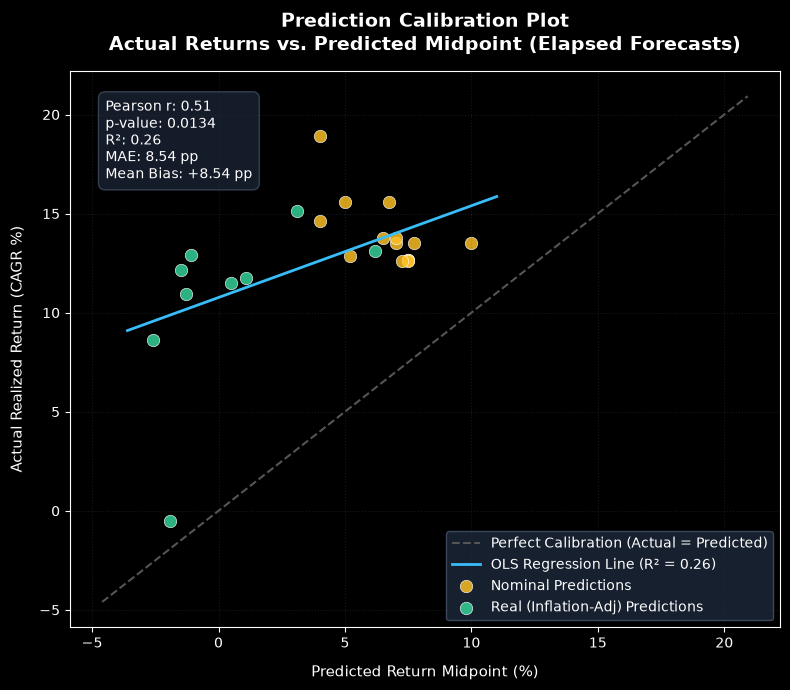

In [5]:
# Generate Calibration Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7))

# Diagonal perfect calibration line
min_val = min(predicted.min(), actual.min()) - 2
max_val = max(predicted.max(), actual.max()) + 2
x_diag = np.linspace(min_val, max_val, 100)
ax.plot(x_diag, x_diag, color='#555555', linestyle='--', linewidth=1.5, label='Perfect Calibration (Actual = Predicted)')

# OLS Regression line
x_reg = np.linspace(predicted.min() - 1, predicted.max() + 1, 100)
y_reg = slope * x_reg + intercept
ax.plot(x_reg, y_reg, color='#38bdf8', linestyle='-', linewidth=2, label=f'OLS Regression Line (R² = {r_squared:.2f})')

# Scatter points colored by return type
nominal_mask = df['Return Type'] == 'nominal'
ax.scatter(df.loc[nominal_mask, 'Predicted Midpoint (%)'], df.loc[nominal_mask, 'Actual Return (CAGR %)'], 
           color='#fbbf24', s=80, alpha=0.85, edgecolors='white', linewidths=0.5, label='Nominal Predictions')
ax.scatter(df.loc[~nominal_mask, 'Predicted Midpoint (%)'], df.loc[~nominal_mask, 'Actual Return (CAGR %)'], 
           color='#34d399', s=80, alpha=0.85, edgecolors='white', linewidths=0.5, label='Real (Inflation-Adj) Predictions')

# Labels and details
ax.set_title('Prediction Calibration Plot\nActual Returns vs. Predicted Midpoint (Elapsed Forecasts)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Return Midpoint (%)', fontsize=11, labelpad=10)
ax.set_ylabel('Actual Realized Return (CAGR %)', fontsize=11, labelpad=10)

# Display statistics box
stats_text = (
    f"Pearson r: {pearson_r:.2f}\n"
    f"p-value: {pearson_p:.4f}\n"
    f"R²: {r_squared:.2f}\n"
    f"MAE: {mae:.2f} pp\n"
    f"Mean Bias: {mean_bias:+.2f} pp"
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e293b', alpha=0.7, edgecolor='#475569'))

ax.legend(loc='lower right', frameon=True, facecolor='#1e293b', edgecolor='#475569')
ax.grid(True, linestyle=':', alpha=0.3, color='#475569')

plt.tight_layout()
plt.show()

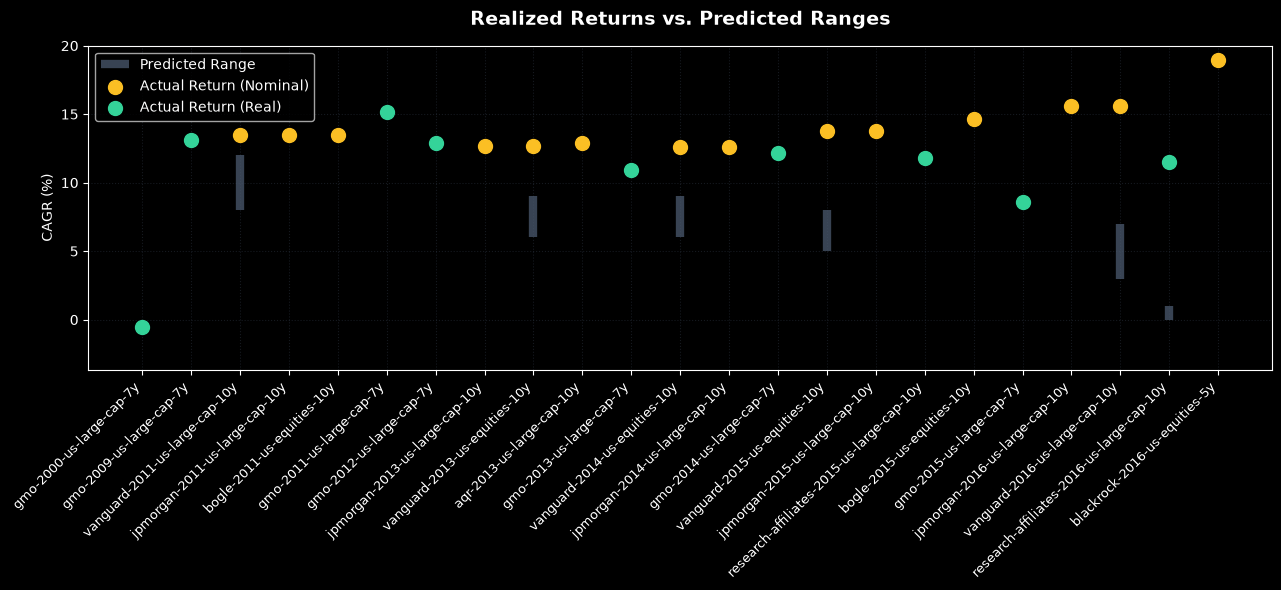

In [6]:
# Generate actual vs predicted ranges comparison bar chart
fig, ax = plt.subplots(figsize=(13, 6))

ids = df['Prediction ID']
x = np.arange(len(ids))

# Plot predicted range as vertical grey bars
for i, p_id in enumerate(ids):
    p_data = [p for p in elapsed if p['id'] == p_id][0]
    ax.vlines(i, p_data['predicted_range'][0], p_data['predicted_range'][1], 
              color='#475569', linewidth=6, alpha=0.8, label='Predicted Range' if i == 0 else "")

# Plot actual return as colored points
ax.scatter(x[nominal_mask], df.loc[nominal_mask, 'Actual Return (CAGR %)'], 
           color='#fbbf24', s=100, zorder=5, label='Actual Return (Nominal)')
ax.scatter(x[~nominal_mask], df.loc[~nominal_mask, 'Actual Return (CAGR %)'], 
           color='#34d399', s=100, zorder=5, label='Actual Return (Real)')

ax.set_title('Realized Returns vs. Predicted Ranges', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('CAGR (%)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.3, color='#475569')
plt.tight_layout()
plt.show()

## 📝 Key Findings and Conclusions
1. **Statistical Significance**: The Pearson correlation coefficient (\(r = 0.5075\)) is positive and carries a \(p\)-value of `0.0134`. This means we can reject the null hypothesis of no relationship—**Wall Street predictions do contain statistically significant information** and are not purely random.
2. **Conservative Compression**: The linear regression slope is `0.4632` (less than 1.0). This indicates that actual realized returns do rise with forecasted returns, but only by about **4.6% for every 10% increase in predicted return**.
3. **Pessimism Intercept**: The OLS regression intercept is **+10.76%**. This shows that even if an organization predicted a 0% return, the market actually yielded a high return on average.
4. **Universal Underestimation (Pessimism Bias)**: The Mean Forecast Bias is **+8.54 pp**, which matches the Mean Absolute Error (MAE) of **8.54 pp**. This confirms that **100% of the completed predictions evaluated underestimated S&P 500 returns**.
